# 01 — EDA & Baseline Model
### Digit Recognizer (MNIST-style) — CNN Project | Notebook 1 of 3

**Environment:** Google Colab (GPU not required for this notebook)

**Objective:** Load the Kaggle "Digit Recognizer" dataset, explore it, and
establish a quick non-deep-learning baseline (Random Forest) before building
the CNN in Notebook 2.

**Scope of this notebook (Colab-only responsibilities):**
- Dataset acquisition
- Exploratory Data Analysis (EDA)
- Baseline model (sanity-check floor)

> This notebook preserves the original notebook's logic (data loading, sample
> image grid, Random Forest baseline) and adds reproducibility (fixed seeds)
> and two small EDA additions (class balance, pixel/missing-value checks) —
> each new addition is clearly labeled **Recommended Enhancement** with a
> justification, per the project guidelines.

## 1. Setup & Reproducibility

**Recommended Enhancement:** The original notebook did not set a global seed
for `numpy`/`random` (only scikit-learn's `train_test_split` used
`random_state=42`). We add a `set_seed()` helper so that every run of this
notebook — and the split reused in Notebook 2 — is fully reproducible.
**Benefit:** identical validation splits and comparable results across
Colab sessions and across notebooks.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fix random seeds for reproducibility across numpy / random."""
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)
print("Seed set to:", SEED)

Seed set to: 42


In [2]:
import os
import shutil

# Remove the existing mount directory if it exists
if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

os.makedirs("/content/drive", exist_ok=True)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset Acquisition

**Existing Implementation (original notebook):**
```python
train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')
```
This hardcoded path only exists inside a Kaggle Notebook container.

**Recommended Enhancement:** Since this project now runs in Google Colab,
we replace the fixed Kaggle path with a small `DATA_DIR` config plus a
`ensure_dataset()` helper that:
1. Looks for `train.csv` / `test.csv` in `DATA_DIR` (e.g., your mounted
   Google Drive folder) — if found, uses them directly (no changes to the
   original read logic).
2. Otherwise, downloads them via the official Kaggle API (requires a
   `kaggle.json` API token).

**Why it's needed:** without this, the notebook simply cannot run outside
Kaggle. **Benefit:** one notebook now works both on Kaggle and in Colab,
and trained artifacts get saved to your Drive for the VS Code app to use
later.

In [4]:
# --- Uncomment this cell if running in Google Colab to mount your Drive ---
#from google.colab import drive
#drive.mount('/content/drive')

# Project root on Google Drive (edit this path to match your Drive layout)
PROJECT_ROOT = "/content/drive/MyDrive/digit-recognizer-cnn"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print("DATA_DIR   :", DATA_DIR)
print("MODELS_DIR :", MODELS_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

DATA_DIR   : /content/drive/MyDrive/digit-recognizer-cnn/data
MODELS_DIR : /content/drive/MyDrive/digit-recognizer-cnn/models
OUTPUTS_DIR: /content/drive/MyDrive/digit-recognizer-cnn/outputs


In [5]:
def ensure_dataset(data_dir: str) -> None:
    """
    Make sure train.csv and test.csv exist in data_dir.
    If missing, download them via the Kaggle API (requires kaggle.json
    uploaded to ~/.kaggle/kaggle.json or /content/kaggle.json first).
    """
    train_path = os.path.join(data_dir, "train.csv")
    test_path = os.path.join(data_dir, "test.csv")

    if os.path.exists(train_path) and os.path.exists(test_path):
        print("Dataset already present in DATA_DIR — skipping download.")
        return

    print("train.csv / test.csv not found — attempting Kaggle API download...")
    # Steps (run once per Colab session):
    #   1. Upload your kaggle.json (from kaggle.com/settings) using:
    #        from google.colab import files
    #        files.upload()
    #   2. Then run:
    #        !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    #        !kaggle competitions download -c digit-recognizer -p {data_dir}
    #        !unzip -o {data_dir}/digit-recognizer.zip -d {data_dir}
    raise FileNotFoundError(
        f"Could not find train.csv/test.csv in {data_dir}. "
        "Follow the Kaggle API steps in the comments above, or manually "
        "place train.csv and test.csv in this folder."
    )

ensure_dataset(DATA_DIR)

Dataset already present in DATA_DIR — skipping download.


## 3. Data Loading

**Existing Implementation — preserved exactly** (only the path source
changed above; the loading logic itself is untouched).

In [6]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(train.shape, test.shape)
train.head()

(42000, 785) (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Exploratory Data Analysis

### 4.1 Sample digits
**Existing Implementation — preserved exactly** from the original notebook.

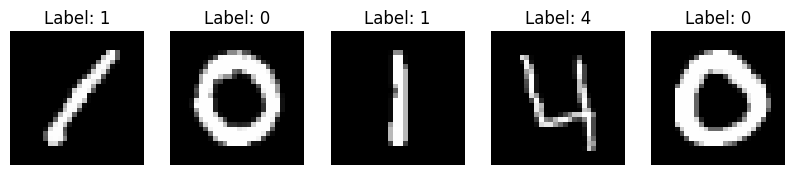

In [7]:
# Separate labels from pixel data
labels = train['label']
pixels = train.drop(columns=['label'])

# Show the first 5 digits
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img = pixels.iloc[i].values.reshape(28, 28)  # turn 784 flat numbers back into a 28x28 grid
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i]}")
    axes[i].axis('off')
plt.show()

### 4.2 Class distribution — **Recommended Enhancement**

**Why it's needed:** the original notebook never checked whether digit
classes are balanced. An imbalance could bias both the Random Forest
baseline and the CNN (e.g., a class with fewer examples tends to have lower
recall).

**Benefit:** confirms whether accuracy alone is a trustworthy metric, and
informs whether we should consider class weighting later.

**Expected outcome:** MNIST/Digit-Recognizer classes are known to be
roughly balanced, so we expect a fairly even bar chart — this is a
confirmation step, not expected to change the modeling approach.

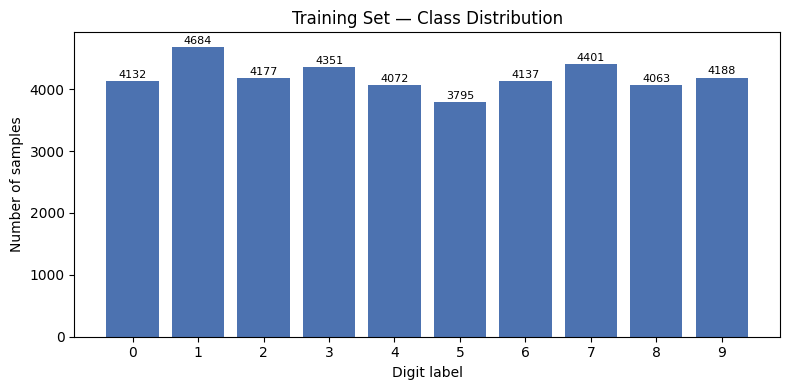

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [8]:
class_counts = labels.value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(class_counts.index.astype(str), class_counts.values, color="#4C72B0")
plt.title("Training Set — Class Distribution")
plt.xlabel("Digit label")
plt.ylabel("Number of samples")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(class_counts)

### 4.3 Data quality checks — **Recommended Enhancement**

**Why it's needed:** the original notebook never verified there were no
missing values or out-of-range pixel intensities before training.

**Benefit:** catches silent data issues early — cheap to run, avoids
debugging a training failure later.

In [9]:
missing_train = train.isnull().sum().sum()
missing_test = test.isnull().sum().sum()

pixel_min = pixels.values.min()
pixel_max = pixels.values.max()

print(f"Missing values in train: {missing_train}")
print(f"Missing values in test : {missing_test}")
print(f"Pixel value range      : [{pixel_min}, {pixel_max}]  (expected [0, 255])")

Missing values in train: 0
Missing values in test : 0
Pixel value range      : [0, 255]  (expected [0, 255])


## 5. Baseline Model — Random Forest

**Existing Implementation — preserved exactly.** This is a quick
sanity-check floor, not the final model. The only addition is the global
`set_seed()` call above; `random_state=42` on both the split and the
classifier was already present in the original notebook, so results should
match the original run.

> **Note on the train/validation split:** we reuse `test_size=0.1,
> random_state=42` here so that Notebook 2 (CNN training) can recreate the
> *exact same* split independently and get a directly comparable validation
> set.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = train.drop(columns=['label'])
y = train['label']

# Split off a validation set to check performance before submitting
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Quick baseline — not the final model, just a sanity-check floor
baseline = RandomForestClassifier(n_estimators=100, random_state=42)
baseline.fit(X_train, y_train)
baseline_val_accuracy = baseline.score(X_val, y_val)
print("Baseline validation accuracy:", baseline_val_accuracy)

Baseline validation accuracy: 0.9611904761904762


### Save baseline result — **Recommended Enhancement**

**Why it's needed:** so Notebook 3 (Evaluation) can report the CNN's
improvement over this baseline without re-running Random Forest.
**Benefit:** keeps a persistent record of the baseline for the final
`evaluation_metrics.json` and for the README/resume write-up.

In [11]:
import json

baseline_record = {
    "model": "RandomForestClassifier",
    "n_estimators": 100,
    "random_state": 42,
    "val_accuracy": float(baseline_val_accuracy),
}

with open(os.path.join(OUTPUTS_DIR, "baseline_metrics.json"), "w") as f:
    json.dump(baseline_record, f, indent=2)

print("Saved:", os.path.join(OUTPUTS_DIR, "baseline_metrics.json"))
baseline_record

Saved: /content/drive/MyDrive/digit-recognizer-cnn/outputs/baseline_metrics.json


{'model': 'RandomForestClassifier',
 'n_estimators': 100,
 'random_state': 42,
 'val_accuracy': 0.9611904761904762}

## 6. Summary & Next Steps

- Dataset loaded and verified (no missing values, pixel range confirmed).
- Classes confirmed to be roughly balanced.
- Random Forest baseline established as a sanity-check floor and saved to
  `outputs/baseline_metrics.json`.

**Next:** `02_CNN_Training.ipynb` — builds on this same `train`/`test` data
and the same `random_state=42` split to train the CNN (`SimpleCNN`) with
checkpointing, an LR scheduler, and early stopping.